# Pruebas de Separación 

In [1]:
#imports
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
from aux_func import *
from sklearn.decomposition import PCA
from scipy.signal import stft, istft

In [2]:
#Importar base de datos
mat=load_mat("C:/Users/34648/Desktop/Clases/4_GITT/TFG/OPENICPSR/TR2_postTMR_32chanEMG.mat") #Esto direccion absoluta cuidado


## Pruebas con 2 caneles con mano abierta

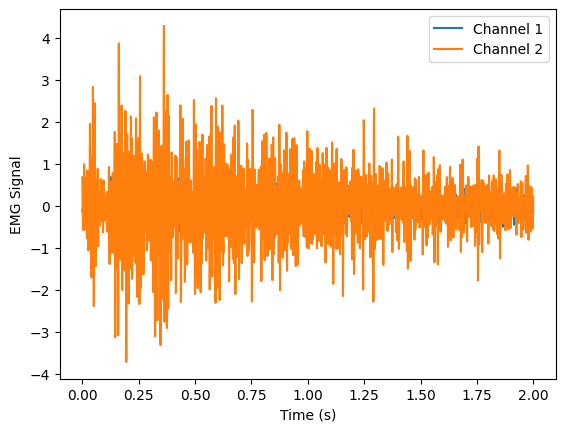

In [3]:
emg=find_movement_rep(mat,"handOpen",rep=1)[0]
ch1=emg[:,0]
ch2=emg[:,20]
fs=1000
ts=1/fs
t=np.arange(0, len(ch1)*ts, ts)
plt.plot(t, ch1, label='Channel 1')
plt.plot(t, ch2, label='Channel 2')
plt.xlabel('Time (s)')
plt.ylabel('EMG Signal')
plt.legend()

## Preprocesado sin filtros
1. Quitar dc
2. Eliminar outliers
3. Escalar los canales

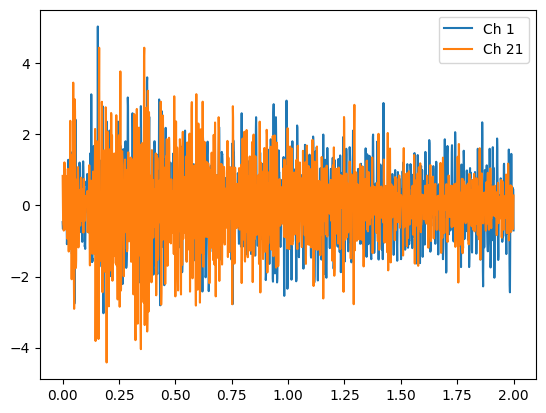

In [4]:
emg = find_movement_rep(mat, "handOpen", rep=1)[0]


emg = eliminar_continua(emg)
emg = eliminar_outiliers(emg, k=8)
emg = escalar_canales(emg, metodo="rms")  # o zscore

ch1 = emg[:, 0]
ch2 = emg[:, 20]

t = np.arange(0, len(ch1) / fs, 1 / fs)

plt.plot(t, ch1, label="Ch 1")
plt.plot(t, ch2, label="Ch 21")  # recuerda: index 20 = canal 21
plt.legend()



# 1. Separación a Ciegas segun independencia estadísitca
## ICA (Independent Component Analysis)

Los primeros algoritmo que se estudiarán son los ICA

## Pruebas de c1 y c2
### Caso 1: dos fuentes con atenuacion bidireccional $\beta$
Empezando con el caso más trivial, la primera prueba es probar a separar 2 señales de canales mas o menos independientes segun las siguientes combinaciones:
- $c_1=s_1 +\beta*s_2$
- $c_2=\beta*s_1 +s_2$

Se busca:
- Comprobar que similaridad entre las componentes independientes (ICs) y la señales originales
- Analizar la matriz de separación
- Observar como varia la separacion segun los valores de $\beta$

In [5]:
from sklearn.discriminant_analysis import StandardScaler


s1 = emg[:, 6]
s2 = emg[:, 27]
S_original = np.c_[s1, s2]
def test_fastica_beta(s1, s2, beta):
    #1 Crear mezcla
    c1 = s1 + beta * s2
    c2 = s2 + 0.01 * s1
    X = np.c_[c1, c2]
    
    #2 Aplicar FastICA
    ica = FastICA(n_components=2, random_state=42, whiten='unit-variance')
    S_derived = ica.fit_transform(X)  # Señales estimadas (ICs)
    W = ica.components_               # Matriz de separación estimada
    
    return X, S_derived, W

#Escoger beta
for beta_test in [0.1, 0.5, 0.8]:
    X, S_derived, W = test_fastica_beta(s1, s2, beta_test)
    S_aligned, C_final = match_and_fix(S_original.T, S_derived.T)
    print(f"ICA finalizado para beta = {beta_test}")

    print("Matriz de correlación final C:\n", C_final)

def isi_metric(W, A):
    """
    W: matriz de separación estimada (2x2)
    A: matriz de mezcla real (2x2)

    Devuelve:
        isi_total
        P = W @ A
    """
    P = W @ A
    P_abs = np.abs(P)

    n = P.shape[0]
    isi_rows = []

    for i in range(n):
        row = P_abs[i, :]
        isi_i = (np.sum(row) / np.max(row)) - 1
        isi_rows.append(isi_i)

    isi_total = np.mean(isi_rows)

    return isi_total, P
A = np.array([[1.0, 0.1], [0.01, 1.0]])

isi, P = isi_metric(W, A)

print("ISI:", isi)
print("P =\n", P)

ICA finalizado para beta = 0.1
Matriz de correlación final C:
 [[ 0.98501227  0.17248427]
 [-0.17351713  0.98483085]]
ICA finalizado para beta = 0.5
Matriz de correlación final C:
 [[ 0.98569517  0.1685379 ]
 [-0.16957148  0.98551789]]
ICA finalizado para beta = 0.8
Matriz de correlación final C:
 [[ 0.98518211  0.17151157]
 [-0.17254461  0.9850017 ]]
ISI: 0.5396189002676983
P =
 [[-0.17254503 -0.87038119]
 [-0.9850041   0.8677857 ]]


In [6]:
import numpy as np
from sklearn.decomposition import FastICA

# Importa tus auxiliares actualizadas
from aux_func import comparar_rms_ventanas, match_and_fix

# ============================================================
# Señales originales
# ============================================================
s1 = emg[:, 6]
s2 = emg[:, 27]
S_original = np.c_[s1, s2]   # shape: (N,2)

# ============================================================
# FastICA con mezcla artificial
# ============================================================
def test_fastica_beta(s1, s2, beta):
    # 1) Crear mezcla
    c1 = s1 + beta * s2
    c2 = s2 + 0.01 * s1
    X = np.c_[c1, c2]

    # 2) Aplicar FastICA
    ica = FastICA(n_components=2, random_state=42, whiten='unit-variance')
    S_derived = ica.fit_transform(X)   # (N,2)
    W = ica.components_                # (2,2)

    return X, S_derived, W

# ============================================================
# Métrica RMS por ventanas para una matriz 2x2
# ============================================================
def matriz_corr_rms_ventanas(S_true, S_est, fs, window_ms=150, step_ms=50):
    """
    S_true: (2,N)
    S_est : (2,N)
    Devuelve matriz 2x2 con correlaciones entre RMS por ventanas.
    """
    C_rms = np.zeros((2, 2))

    for i in range(2):
        for j in range(2):
            _, _, corr = comparar_rms_ventanas(
                S_true[i], S_est[j], fs,
                window_ms=window_ms,
                step_ms=step_ms
            )
            C_rms[i, j] = corr

    return C_rms

# ============================================================
# Bucle principal
# ============================================================
fs = 1000
window_ms = 150
step_ms = 50

for beta_test in [0.1, 0.5, 0.8]:
    print("\n" + "=" * 60)
    print(f"Probando beta = {beta_test}")

    # Mezcla + ICA
    X, S_derived, W = test_fastica_beta(s1, s2, beta_test)

    # Alineación por correlación temporal normal
    S_aligned, C_final = match_and_fix(S_original.T, S_derived.T)

    print("ICA finalizado")
    print("Matriz de correlación temporal final C:")
    print(C_final)

    # Comparación usando RMS por ventanas
    C_rms = matriz_corr_rms_ventanas(
        S_original.T, S_aligned,
        fs=fs,
        window_ms=window_ms,
        step_ms=step_ms
    )

    print("Matriz de correlación entre mean RMS por ventanas:")
    print(C_rms)

    print(f"RMS corr s1 vs comp1: {C_rms[0,0]:.4f}")
    print(f"RMS corr s2 vs comp2: {C_rms[1,1]:.4f}")



Probando beta = 0.1
ICA finalizado
Matriz de correlación temporal final C:
[[ 0.98501227  0.17248427]
 [-0.17351713  0.98483085]]
Matriz de correlación entre mean RMS por ventanas:
[[0.99586883 0.90556086]
 [0.91029454 0.99822265]]
RMS corr s1 vs comp1: 0.9959
RMS corr s2 vs comp2: 0.9982

Probando beta = 0.5
ICA finalizado
Matriz de correlación temporal final C:
[[ 0.98569517  0.1685379 ]
 [-0.16957148  0.98551789]]
Matriz de correlación entre mean RMS por ventanas:
[[0.99606782 0.9052509 ]
 [0.90984082 0.99830753]]
RMS corr s1 vs comp1: 0.9961
RMS corr s2 vs comp2: 0.9983

Probando beta = 0.8
ICA finalizado
Matriz de correlación temporal final C:
[[ 0.98518211  0.17151157]
 [-0.17254461  0.9850017 ]]
Matriz de correlación entre mean RMS por ventanas:
[[0.99591838 0.90548425]
 [0.91018243 0.99824379]]
RMS corr s1 vs comp1: 0.9959
RMS corr s2 vs comp2: 0.9982


In [7]:
from scipy.signal import find_peaks
import numpy as np


def detectar_picos_rms(signal, fs, window_ms=150, step_ms=50,
                       prominence=0.0, distance_ms=200):
    """
    Calcula RMS por ventanas y detecta picos de activación.

    Devuelve:
        rms_vals
        peaks_idx
        peaks_time
    """

    rms_vals = rms_ventanas(signal, fs, window_ms, step_ms)

    distance = int(distance_ms / step_ms)

    peaks_idx, _ = find_peaks(
        rms_vals,
        prominence=prominence,
        distance=distance
    )

    peaks_time = peaks_idx * (step_ms / 1000)

    return rms_vals, peaks_idx, peaks_time

def comparar_picos_rms(x, y, fs, window_ms=150, step_ms=50,
                       prominence=0.0, tolerance_ms=100):
    """
    Compara picos de activación entre dos señales.

    Devuelve:
        match_ratio
        n_peaks_x
        n_peaks_y
    """

    _, peaks_x, _ = detectar_picos_rms(x, fs, window_ms, step_ms, prominence)
    _, peaks_y, _ = detectar_picos_rms(y, fs, window_ms, step_ms, prominence)

    tolerance = int(tolerance_ms / step_ms)

    matches = 0

    for px in peaks_x:
        if np.any(np.abs(peaks_y - px) <= tolerance):
            matches += 1

    if len(peaks_x) == 0:
        match_ratio = 0
    else:
        match_ratio = matches / len(peaks_x)

    return match_ratio, len(peaks_x), len(peaks_y)

def matriz_match_picos(S_true, S_est, fs, window_ms=150, step_ms=50):

    C = np.zeros((2,2))

    for i in range(2):
        for j in range(2):

            match_ratio, _, _ = comparar_picos_rms(
                S_est[j],
                S_true[i],
                fs,
                window_ms,
                step_ms
            )

            C[i,j] = match_ratio

    return C

for beta_test in [0.1,0.5,0.8]:

    X, S_derived, W = test_fastica_beta(s1, s2, beta_test)

    S_aligned, C_final = match_and_fix(S_original.T, S_derived.T)

    print(f"\nProbando beta = {beta_test}")
    print("ICA finalizado")

    print("Matriz correlación temporal:")
    print(C_final)

    C_peaks = matriz_match_picos(
        S_original.T,
        S_aligned,
        fs=1000,
        window_ms=150,
        step_ms=50
    )

    print("Coincidencia de picos de activación:")
    print(C_peaks)


Probando beta = 0.1
ICA finalizado
Matriz correlación temporal:
[[ 0.98501227  0.17248427]
 [-0.17351713  0.98483085]]
Coincidencia de picos de activación:
[[1.         0.66666667]
 [0.8        1.        ]]

Probando beta = 0.5
ICA finalizado
Matriz correlación temporal:
[[ 0.98569517  0.1685379 ]
 [-0.16957148  0.98551789]]
Coincidencia de picos de activación:
[[1.         0.66666667]
 [0.8        1.        ]]

Probando beta = 0.8
ICA finalizado
Matriz correlación temporal:
[[ 0.98518211  0.17151157]
 [-0.17254461  0.9850017 ]]
Coincidencia de picos de activación:
[[1.         0.66666667]
 [0.8        1.        ]]


In [8]:
import numpy as np
from sklearn.decomposition import FastICA
from scipy.signal import find_peaks

# ============================================================
# SEÑALES ORIGINALES
# ============================================================
# Ajusta estas líneas si quieres usar otros canales
s1 = emg[:, 26]
s2 = emg[:, 27]
S_original = np.c_[s1, s2]   # (N, 2)

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================
def delay_signal(x, delay_samples):
    """
    Retrasa una señal sin wrap-around.
    delay_samples > 0 -> retrasa la señal
    delay_samples < 0 -> adelanta la señal
    """
    x = np.asarray(x)
    y = np.zeros_like(x)

    if delay_samples > 0:
        y[delay_samples:] = x[:-delay_samples]
    elif delay_samples < 0:
        d = abs(delay_samples)
        y[:-d] = x[d:]
    else:
        y = x.copy()

    return y




def detectar_picos_rms(signal, fs, window_ms=150, step_ms=50,
                       prominence=0.0, distance_ms=200):
    """
    Calcula RMS por ventanas y detecta picos.
    """
    rms_vals = rms_ventanas(signal, fs, window_ms, step_ms)

    distance = max(1, int(distance_ms / step_ms))

    peaks_idx, _ = find_peaks(
        rms_vals,
        prominence=prominence,
        distance=distance
    )

    peaks_time = peaks_idx * (step_ms / 1000)

    return rms_vals, peaks_idx, peaks_time


def comparar_picos_rms_con_lag(x, y, fs, window_ms=150, step_ms=50,
                               prominence=0.0, tolerance_ms=100,
                               lag_ms=0):
    """
    Compara picos RMS permitiendo un lag fijo.

    lag_ms > 0: y ocurre más tarde que x
    lag_ms < 0: y ocurre antes que x

    Devuelve:
        match_ratio
        n_peaks_x
        n_peaks_y
        lag_samples
    """
    _, peaks_x, _ = detectar_picos_rms(
        x, fs, window_ms, step_ms, prominence=prominence
    )
    _, peaks_y, _ = detectar_picos_rms(
        y, fs, window_ms, step_ms, prominence=prominence
    )

    tolerance = max(0, int(tolerance_ms / step_ms))
    lag_samples = int(lag_ms / step_ms)

    peaks_y_shifted = peaks_y + lag_samples

    matches = 0
    used_y = np.zeros(len(peaks_y_shifted), dtype=bool)

    for px in peaks_x:
        valid = np.where((np.abs(peaks_y_shifted - px) <= tolerance) & (~used_y))[0]
        if len(valid) > 0:
            best = valid[np.argmin(np.abs(peaks_y_shifted[valid] - px))]
            used_y[best] = True
            matches += 1

    match_ratio = matches / len(peaks_x) if len(peaks_x) > 0 else 0.0

    return match_ratio, len(peaks_x), len(peaks_y), lag_samples


def buscar_mejor_lag_picos_rms(x, y, fs, window_ms=150, step_ms=50,
                               prominence=0.0, tolerance_ms=100,
                               max_lag_ms=300):
    """
    Busca el lag que maximiza la coincidencia de picos RMS.
    """
    candidate_lags = np.arange(-max_lag_ms, max_lag_ms + step_ms, step_ms)

    best_match = -1.0
    best_lag_ms = 0
    best_nx = 0
    best_ny = 0

    for lag_ms in candidate_lags:
        match_ratio, nx, ny, _ = comparar_picos_rms_con_lag(
            x, y, fs,
            window_ms=window_ms,
            step_ms=step_ms,
            prominence=prominence,
            tolerance_ms=tolerance_ms,
            lag_ms=lag_ms
        )

        if match_ratio > best_match:
            best_match = match_ratio
            best_lag_ms = lag_ms
            best_nx = nx
            best_ny = ny

    return best_match, best_lag_ms, best_nx, best_ny


def matriz_match_picos_lag(S_true, S_est, fs, window_ms=150, step_ms=50,
                           prominence=0.0, tolerance_ms=100,
                           max_lag_ms=300):
    """
    Para matrices con forma (2, N), calcula:
    - C_match: coincidencia de picos con mejor lag
    - C_lag: lag óptimo en ms
    """
    C_match = np.zeros((2, 2))
    C_lag = np.zeros((2, 2))

    for i in range(2):
        for j in range(2):
            best_match, best_lag_ms, _, _ = buscar_mejor_lag_picos_rms(
                S_est[j],
                S_true[i],
                fs,
                window_ms=window_ms,
                step_ms=step_ms,
                prominence=prominence,
                tolerance_ms=tolerance_ms,
                max_lag_ms=max_lag_ms
            )
            C_match[i, j] = best_match
            C_lag[i, j] = best_lag_ms

    return C_match, C_lag


def corr_matrix(S_true_T, S_est_T):
    """
    Matriz de correlación absoluta entre filas.
    Entrada esperada: (2, N) y (2, N)
    """
    C = np.zeros((2, 2))
    for i in range(2):
        for j in range(2):
            C[i, j] = np.corrcoef(S_true_T[i], S_est_T[j])[0, 1]
    return C





# ============================================================
# MEZCLA CON TAU
# ============================================================
def mezclar_con_tau(s1, s2, beta, tau_ms, fs):
    """
    Mezcla con retardo tau aplicado a s2 en c1:
        c1 = s1 + beta * s2(t - tau)
        c2 = s2 + 0.01 * s1
    """
    tau_samples = int(tau_ms * fs / 1000)
    s2_delayed = delay_signal(s2, tau_samples)

    c1 = s1 + beta * s2_delayed
    c2 = s2 + 0.01 * s1

    X = np.c_[c1, c2]
    return X


def test_fastica_tau(s1, s2, beta, tau_ms, fs):
    X = mezclar_con_tau(s1, s2, beta, tau_ms, fs)

    ica = FastICA(n_components=2, random_state=42, whiten='unit-variance')
    S_derived = ica.fit_transform(X)   # (N, 2)
    W = ica.components_

    return X, S_derived, W


# ============================================================
# EXPERIMENTO: BETA FIJO, VARIOS TAU
# ============================================================
fs = 1000
beta = 0.5
taus_ms = [0, 10, 25, 50, 100, 150, 200]

window_ms = 150
step_ms = 50
prominence = 0.0
tolerance_ms = 100
max_lag_ms = 300

print(f"\n===== EXPERIMENTO CON beta = {beta} =====")

for tau in taus_ms:
    print("\n" + "=" * 70)
    print(f"beta = {beta}, tau = {tau} ms")

    X, S_derived, W = test_fastica_tau(s1, s2, beta, tau, fs)

    # Alineación de componentes
    S_aligned_T, C_final = match_and_fix(S_original.T, S_derived.T)

    print("ICA finalizado")
    print("Matriz correlación temporal:")
    print(C_final)

    # Coincidencia de picos RMS permitiendo lag
    C_peaks, C_lags = matriz_match_picos_lag(
        S_original.T,
        S_aligned_T,
        fs=fs,
        window_ms=window_ms,
        step_ms=step_ms,
        prominence=prominence,
        tolerance_ms=tolerance_ms,
        max_lag_ms=max_lag_ms
    )

    print("Coincidencia de picos de activación (con mejor lag):")
    print(C_peaks)

    print("Lag óptimo detectado (ms):")
    print(C_lags)

    print(f"Resumen s1->comp1: corr={C_final[0,0]:.4f}, peak_match={C_peaks[0,0]:.4f}, lag={C_lags[0,0]:.1f} ms")
    print(f"Resumen s2->comp2: corr={C_final[1,1]:.4f}, peak_match={C_peaks[1,1]:.4f}, lag={C_lags[1,1]:.1f} ms")


===== EXPERIMENTO CON beta = 0.5 =====

beta = 0.5, tau = 0 ms
ICA finalizado
Matriz correlación temporal:
[[ 0.88593516  0.46380911]
 [-0.00529763  0.99998597]]
Coincidencia de picos de activación (con mejor lag):
[[1.         0.66666667]
 [1.         1.        ]]
Lag óptimo detectado (ms):
[[-100. -300.]
 [-300. -100.]]
Resumen s1->comp1: corr=0.8859, peak_match=1.0000, lag=-100.0 ms
Resumen s2->comp2: corr=1.0000, peak_match=1.0000, lag=-100.0 ms

beta = 0.5, tau = 10 ms
ICA finalizado
Matriz correlación temporal:
[[0.89021506 0.15016921]
 [0.36045933 0.93276502]]
Coincidencia de picos de activación (con mejor lag):
[[1.  0.8]
 [0.8 1. ]]
Lag óptimo detectado (ms):
[[-100. -100.]
 [-300.   50.]]
Resumen s1->comp1: corr=0.8902, peak_match=1.0000, lag=-100.0 ms
Resumen s2->comp2: corr=0.9328, peak_match=1.0000, lag=50.0 ms

beta = 0.5, tau = 25 ms
ICA finalizado
Matriz correlación temporal:
[[ 0.58712506  0.69046298]
 [-0.32653164  0.94517683]]
Coincidencia de picos de activación (co

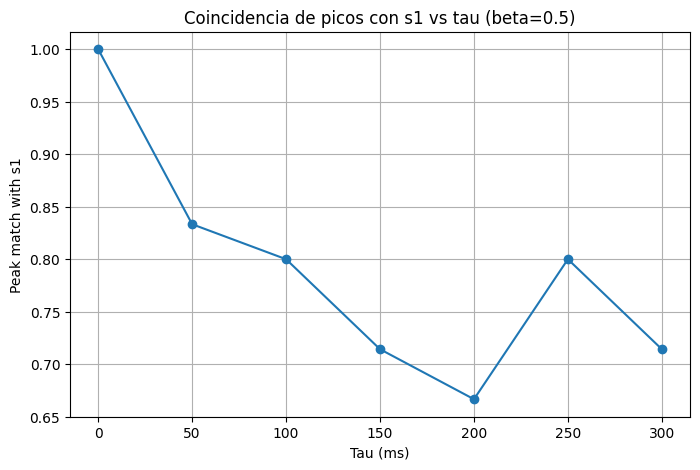

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# Parámetros
# =========================================
fs = 1000
beta = 0.5
taus_ms = [0, 50, 100, 150, 200, 250, 300]   # 0 a 200 ms en pasos de 25 ms

window_ms = 150
step_ms = 50
prominence = 0.0
tolerance_ms = 100
max_lag_ms = 300

# =========================================
# Guardar resultados
# =========================================
peak_match_s1 = []
best_lag_s1 = []
corr_s1 = []

for tau in taus_ms:
    X, S_derived, W = test_fastica_tau(s1, s2, beta, tau, fs)

    S_aligned_T, C_final = match_and_fix(S_original.T, S_derived.T)

    C_peaks, C_lags = matriz_match_picos_lag(
        S_original.T,
        S_aligned_T,
        fs=fs,
        window_ms=window_ms,
        step_ms=step_ms,
        prominence=prominence,
        tolerance_ms=tolerance_ms,
        max_lag_ms=max_lag_ms
    )

    # s1 frente a comp1
    peak_match_s1.append(C_peaks[0, 0])
    best_lag_s1.append(C_lags[0, 0])
    corr_s1.append(C_final[0, 0])

# =========================================
# Gráfica principal: coincidencia de picos
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(taus_ms, peak_match_s1, marker='o')
plt.xlabel('Tau (ms)')
plt.ylabel('Peak match with s1')
plt.title(f'Coincidencia de picos con s1 vs tau (beta={beta})')
plt.grid(True)
plt.show()

In [10]:
def analizar_similaridad(S_orig, S_est):
    n_src = S_orig.shape[1]
    correlaciones = np.zeros((n_src, n_src))
    
    for i in range(n_src):
        for j in range(n_src):
            matriz_corr = np.corrcoef(S_orig[:, i], S_est[:, j])
            corr_valor = matriz_corr[0, 1]
            
            #ICA invierte fases sin saber-> Tomar valor absoluto!!!!!!!!!!!!!!!
            correlaciones[i, j] = abs(corr_valor)
            
    return correlaciones

# Ejecutamos el análisis
corrs = analizar_similaridad(S_original, S_derived)

print("Matriz de Correlación (Filas: Fuentes Originales, Columnas: ICs recuperadas):")
print(np.round(corrs, 4))

# Identificar qué IC corresponde a qué fuente
for i in range(corrs.shape[0]):
    best_match = np.argmax(corrs[i, :])
    print(f"La Señal Original {i+1} coincide mejor con la IC {best_match+1} (Corr: {corrs[i, best_match]:.4f})")

Matriz de Correlación (Filas: Fuentes Originales, Columnas: ICs recuperadas):
[[0.3896 0.8168]
 [0.996  0.0892]]
La Señal Original 1 coincide mejor con la IC 2 (Corr: 0.8168)
La Señal Original 2 coincide mejor con la IC 1 (Corr: 0.9960)


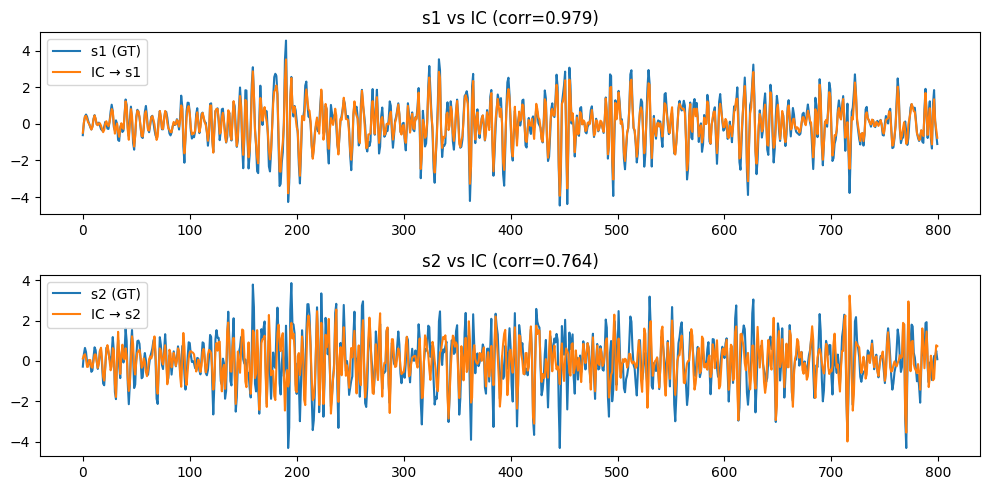

In [11]:
from scipy.optimize import linear_sum_assignment


def match_and_fix(S_true, S_est):
    C = corr_matrix(S_true, S_est)
    cost = 1 - np.abs(C)
    rows, cols = linear_sum_assignment(cost)

    S_al = S_est[cols, :].copy()
    matched_corr = C[rows, cols]
    signs = np.sign(matched_corr)
    signs[signs == 0] = 1
    S_al *= signs[:, None]

    C_final = corr_matrix(S_true, S_al)
    return S_al, C_final

# -----------------------------
# 1) Fuentes reales (ground truth)
# -----------------------------
emg = find_movement_rep(mat, "handOpen", rep=1)[0]
emg = eliminar_continua(emg)
emg = eliminar_outiliers(emg, k=8)
emg = escalar_canales(emg, metodo="rms")

s1 = emg[:, 25]
s2 = emg[:, 27]
S = np.vstack([s1, s2])

# limitar longitud para claridad
N = 800
S = S[:, :N]

#Matriz de mezcla
A = np.array([[1, 0.7],
              [0.7, 1]])

X = A @ S


ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2000,   # pocas iteraciones
    tol=1e-12
)
S_hat = ica.fit_transform(X.T).T
S_aligned, C_final = match_and_fix(S, S_hat)

t = np.arange(N)

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(t, S[0], label="s1 (GT)")
plt.plot(t, S_aligned[0], label="IC → s1")
plt.title(f"s1 vs IC (corr={C_final[0,0]:.3f})")
plt.legend()

plt.subplot(2,1,2)
plt.plot(t, S[1], label="s2 (GT)")
plt.plot(t, S_aligned[1], label="IC → s2")
plt.title(f"s2 vs IC (corr={C_final[1,1]:.3f})")
plt.legend()

plt.tight_layout()
plt.show()


## Entonces, a que afecta Beta?

In [12]:
def amari_error(W, A):
    """
    Amari error entre la matriz de separación W y la de mezcla A.
    Invariante a escala, signo y permutación.
    """
    P = W @ A
    P = np.abs(P)

    n = P.shape[0]

    row = np.sum(P, axis=1) - np.max(P, axis=1)
    col = np.sum(P, axis=0) - np.max(P, axis=0)

    return (row.sum() + col.sum()) / (2 * n)


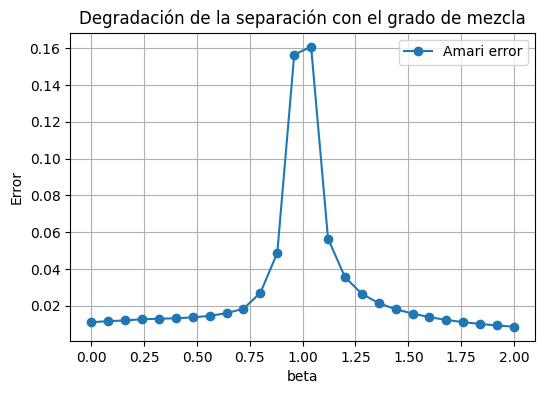

In [13]:
betas = np.linspace(0.0, 2, 26)
amari_vals = []
cond_vals = []

for beta in betas:
    A = np.array([[1.0, beta],
                  [beta, 1.0]])
    X = A @ S

    ica = FastICA(
        n_components=2,
        whiten="unit-variance",
        random_state=0,
        max_iter=2000,
        tol=1e-5
    )
    S_ = ica.fit_transform(X.T).T
    W = ica.components_  @ ica.whitening_


    amari_vals.append(amari_error(W, A))
    cond_vals.append(np.linalg.cond(A))

plt.figure(figsize=(6, 4))
plt.plot(betas, amari_vals, "o-", label="Amari error")
plt.xlabel("beta")
plt.ylabel("Error")
plt.grid(True)
plt.legend()
plt.title("Degradación de la separación con el grado de mezcla")
plt.show()


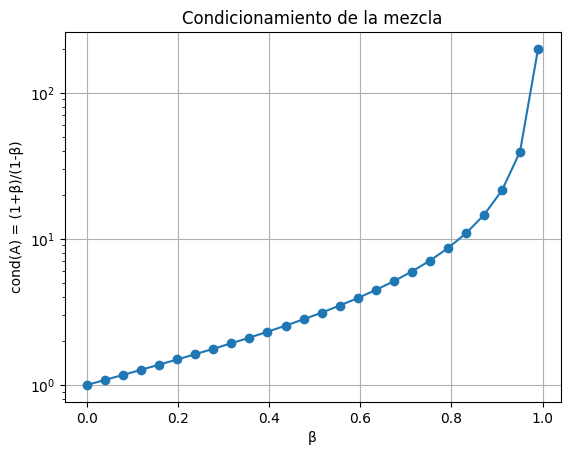

In [14]:
betas = np.linspace(0.0, 0.99, 26)
kappa = [(1+b)/(1-b) for b in betas]
plt.semilogy(betas, kappa, marker="o")
plt.xlabel("β")
plt.ylabel("cond(A) = (1+β)/(1-β)")
plt.title("Condicionamiento de la mezcla")
plt.grid(True)
plt.show()

Matriz de correlación fuente ↔ IC (sin matching):
[[0.11418731 0.99345924]
 [0.92606206 0.37737126]]

Asignación (fuente -> IC): {'s1': 'IC2', 's2': 'IC1'}
Signos aplicados: [1. 1.]

Matriz de correlación fuente ↔ IC (con matching + signo):
[[0.99345924 0.11418731]
 [0.37737126 0.92606206]]


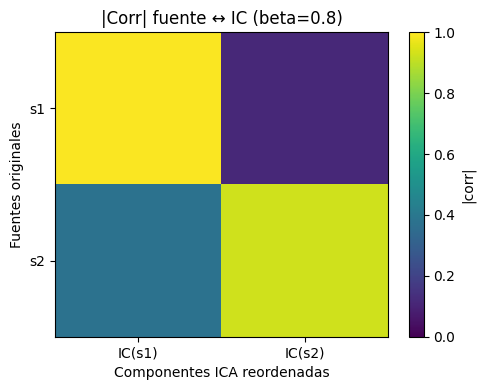

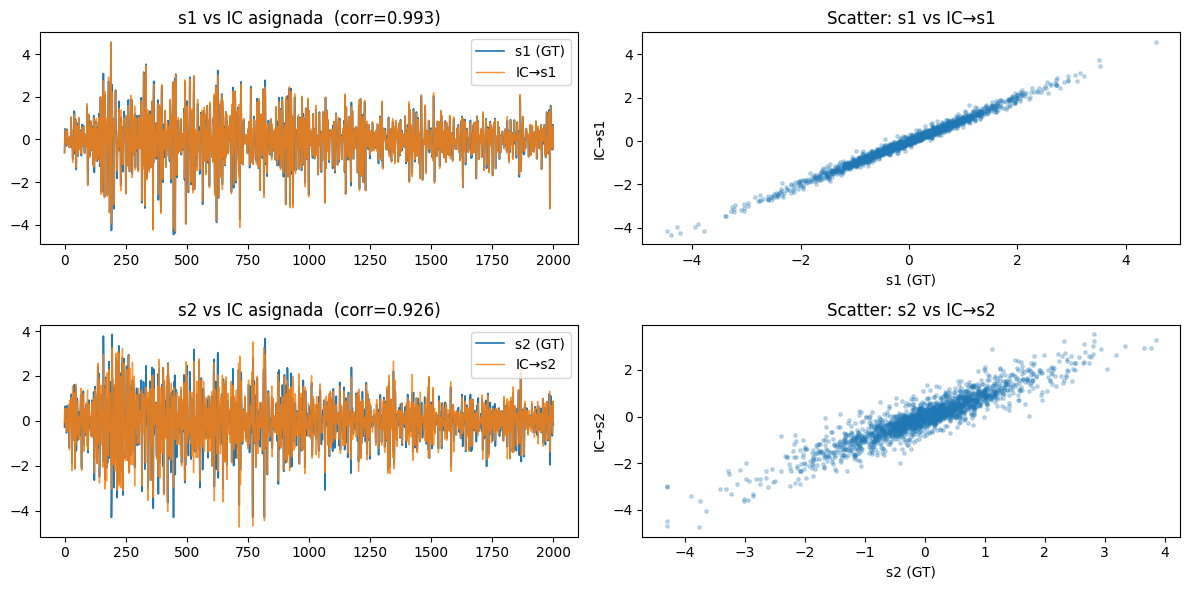

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA

# -----------------------------
# Cargar + preprocesar
# -----------------------------
emg = find_movement_rep(mat, "handOpen", rep=1)[0]

emg = eliminar_continua(emg)
emg = eliminar_outiliers(emg, k=8)
emg = escalar_canales(emg, metodo="rms")  # o "zscore"

s1 = emg[:, 25]
s2 = emg[:, 27]

S = np.vstack([s1, s2])  # (2, N)

# -----------------------------
# Mezcla (ground truth)
# -----------------------------
beta = 0.8
A = np.array([[1.0, beta],
              [0.01, 1.0]])

X = A @ S  # (2, N)

# -----------------------------
# ICA
# -----------------------------
ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2000,
    tol=1e-5
)

S_hat = ica.fit_transform(X.T).T  
W = ica.components_               

# -----------------------------
# Correlación + matching (Hungarian) + corrección de signo
# -----------------------------
C = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        C[i, j] = np.corrcoef(S[i], S_hat[j])[0, 1]

# Hungarian sobre |corr|
cost = 1.0 - np.abs(C)
rows, cols = linear_sum_assignment(cost)  # rows=[0,1], cols = IC asignada a cada fuente

# Reordenar ICs para que coincidan con s1,s2
S_hat_ord = S_hat[cols, :].copy()  # (2, N) en el orden de las fuentes

matched_corr = C[rows, cols]          # (2,)  correlaciones emparejadas (con signo)
signs = np.sign(matched_corr)         # (2,)
signs[signs == 0] = 1.0
S_hat_ord = S_hat_ord * signs[:, None]  # (2,N) OK

#Correlacion
C_final = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        C_final[i, j] = np.corrcoef(S[i], S_hat_ord[j])[0, 1]

print("Matriz de correlación fuente ↔ IC (sin matching):")
print(C)
print("\nAsignación (fuente -> IC):", {f"s{i+1}": f"IC{cols[i]+1}" for i in range(2)})
print("Signos aplicados:", signs)
print("\nMatriz de correlación fuente ↔ IC (con matching + signo):")
print(C_final)

# -----------------------------
# Heatmap |corr|
# -----------------------------
plt.figure(figsize=(5, 4))
plt.imshow(np.abs(C_final), vmin=0, vmax=1, aspect="auto")
plt.colorbar(label="|corr|")
plt.xticks([0, 1], ["IC(s1)", "IC(s2)"])
plt.yticks([0, 1], ["s1", "s2"])
plt.xlabel("Componentes ICA reordenadas")
plt.ylabel("Fuentes originales")
plt.title(f"|Corr| fuente ↔ IC (beta={beta})")
plt.tight_layout()
plt.show()

# -----------------------------
# Representación IC vs ground truth (overlay + scatter)
# -----------------------------
N = S.shape[1]
t = np.arange(N) 

fig = plt.figure(figsize=(12, 6))

# s1 vs IC asignada a s1
ax1 = plt.subplot(2, 2, 1)
ax1.plot(t, S[0], label="s1 (GT)", linewidth=1.2)
ax1.plot(t, S_hat_ord[0], label="IC→s1", linewidth=1.0, alpha=0.85)
ax1.set_title(f"s1 vs IC asignada  (corr={np.corrcoef(S[0], S_hat_ord[0])[0,1]:.3f})")
ax1.legend(loc="upper right")

ax2 = plt.subplot(2, 2, 2)
ax2.scatter(S[0], S_hat_ord[0], s=6, alpha=0.25)
ax2.set_xlabel("s1 (GT)")
ax2.set_ylabel("IC→s1")
ax2.set_title("Scatter: s1 vs IC→s1")

# s2 vs IC asignada a s2
ax3 = plt.subplot(2, 2, 3)
ax3.plot(t, S[1], label="s2 (GT)", linewidth=1.2)
ax3.plot(t, S_hat_ord[1], label="IC→s2", linewidth=1.0, alpha=0.85)
ax3.set_title(f"s2 vs IC asignada  (corr={np.corrcoef(S[1], S_hat_ord[1])[0,1]:.3f})")
ax3.legend(loc="upper right")

ax4 = plt.subplot(2, 2, 4)
ax4.scatter(S[1], S_hat_ord[1], s=6, alpha=0.25)
ax4.set_xlabel("s2 (GT)")
ax4.set_ylabel("IC→s2")
ax4.set_title("Scatter: s2 vs IC→s2")

plt.tight_layout()
plt.show()



### Caso 1.b. Dos fuentes con atenuacion bidireccional $\beta$ y ruido

\begin{aligned}
c_1 &= s_1 + \beta\, s_2 + n_1 \\
c_2 &= s_2 + \beta\, s_1 + n_2 \\
n_1, n_2 & \;\text{independientes} \;\sim\; \mathcal{N}(0,\texttt{noise\_level}^2)
\end{aligned}

NOTA: se considera ruido blanco y gausiano




In [16]:
import numpy as np
from sklearn.decomposition import FastICA

def test_fastica_con_ruido(s1, s2, beta, noise_level=0.0, random_state=0,
                           max_iter=2000, tol=1e-12):
    """
    Mezcla 2 fuentes con A=[[1,b],[b,1]] y añade ruido gaussiano N(0, noise_level^2) a los canales observados.
    Devuelve S_est con shape (N,2) para que encaje con tu código.
    """
    s1 = np.asarray(s1, dtype=float).ravel()
    s2 = np.asarray(s2, dtype=float).ravel()
    N = min(len(s1), len(s2))
    s1 = s1[:N]
    s2 = s2[:N]

    # Fuentes (2,N)
    S = np.vstack([s1, s2])

    # Mezcla (2,N)
    A = np.array([[1.0, beta],
                  [0.01, 1.0]], dtype=float)
    X = A @ S

    # Ruido aditivo en los canales observados
    if noise_level and noise_level > 0:
        X = X + np.random.normal(0.0, noise_level, size=X.shape)

    # ICA (espera (N, n_features))
    ica = FastICA(n_components=2, whiten="unit-variance",
                  random_state=random_state, max_iter=max_iter, tol=tol)

    S_est = ica.fit_transform(X.T)  # (N,2)
    return S_est


def calcular_max_corr(S_original, S_est):
    """
    Calcula la similaridad media (Pearson) entre S_original (N,2) y S_est (N,2)
    probando las dos asignaciones posibles e ignorando signo (abs(corr)).
    Devuelve un escalar en [0,1].
    """
    S_original = np.asarray(S_original, dtype=float)
    S_est = np.asarray(S_est, dtype=float)

    # corr(i,j) = corr( fuente i, componente j )
    def pearson(x, y):
        # robusto a medias/escala
        x = x - x.mean()
        y = y - y.mean()
        denom = (np.sqrt(np.sum(x*x)) * np.sqrt(np.sum(y*y)) + 1e-12)
        return float(np.sum(x*y) / denom)

    c00 = abs(pearson(S_original[:, 0], S_est[:, 0]))
    c01 = abs(pearson(S_original[:, 0], S_est[:, 1]))
    c10 = abs(pearson(S_original[:, 1], S_est[:, 0]))
    c11 = abs(pearson(S_original[:, 1], S_est[:, 1]))

    # Dos asignaciones posibles (2x2): (0->0,1->1) o (0->1,1->0)
    score_id = 0.5 * (c00 + c11)
    score_sw = 0.5 * (c01 + c10)

    return max(score_id, score_sw)


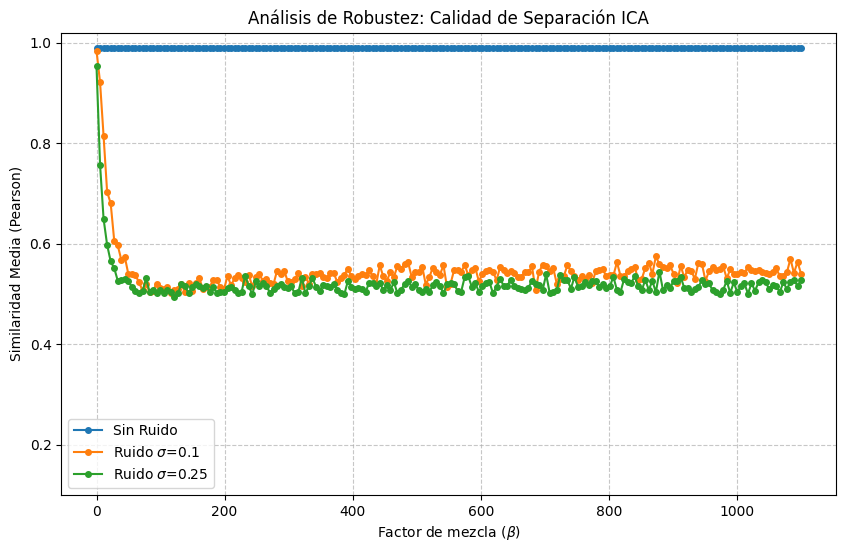

In [17]:
import matplotlib.pyplot as plt
s1 = emg[:, 6]
s2 = emg[:, 27]
S_original = np.c_[s1, s2]
#Evitar beta=1.0 (esto da in condicionamiento infinito!!!!!!!!!!!!!!!!!!!!!!!!)
betas = np.linspace(0, 1100, 200)
niveles_ruido = [0.0, 0.1, 0.25] 
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(10, 6))

for noise, color in zip(niveles_ruido, colores):
    mejor_corr_por_beta = []
    
    for b in betas:
        S_est = test_fastica_con_ruido(s1, s2, b, noise_level=noise)
        mejor_corr_por_beta.append(calcular_max_corr(S_original, S_est))
    
    label = "Sin Ruido" if noise == 0 else f"Ruido $\sigma$={noise}"
    plt.plot(betas, mejor_corr_por_beta, 'o-', label=label, color=color, markersize=4)

plt.title("Análisis de Robustez: Calidad de Separación ICA")
plt.xlabel("Factor de mezcla ($\\beta$)")
plt.ylabel("Similaridad Media (Pearson)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim(0.1, 1.02) 
plt.show()

In [18]:
import numpy as np
from itertools import combinations

def canales_menor_correlacion(emg):
    """
    emg: array (n_samples, n_channels)
    Devuelve:
      (i, j): índices de los canales
      corr: correlación entre ellos
    """
    n_channels = emg.shape[1]

    min_corr = np.inf
    best_pair = None

    for i, j in combinations(range(n_channels), 2):
        c = np.corrcoef(emg[:, i], emg[:, j])[0, 1]
        if np.abs(c) < min_corr:
            min_corr = np.abs(c)
            best_pair = (i, j)
            best_corr = c

    return best_pair, best_corr
(pair, corr) = canales_menor_correlacion(emg)
print(f"Canales con menor correlación: {pair}")
print(f"Correlación: {corr:.4f}")


Canales con menor correlación: (6, 27)
Correlación: -0.0010


In [19]:
import numpy as np
from itertools import combinations

def canales_mayor_correlacion(emg):
    """
    emg: array (n_samples, n_channels)

    Devuelve:
      (i, j): índices de los canales con mayor correlación (en valor absoluto)
      corr: correlación real (con signo)
    """
    n_channels = emg.shape[1]

    max_corr = -np.inf
    best_pair = None

    for i, j in combinations(range(n_channels), 2):
        c = np.corrcoef(emg[:, i], emg[:, j])[0, 1]
        if np.abs(c) > max_corr:
            max_corr = np.abs(c)
            best_pair = (i, j)
            best_corr = c

    return best_pair, best_corr
(pair, corr) = canales_mayor_correlacion(emg)
print(f"Canales con mayor correlación: {pair}")
print(f"Correlación: {corr:.4f}")


Canales con mayor correlación: (28, 29)
Correlación: 0.8558


## Caso 2: Atenuaciones unilaterales

En este caso se considera que a cada electrodo le llega cada señal con atenuaciones diferentes.

\begin{aligned}
c_1 &= a_{11} s_1 + a_{12} s_2 \\
c_2 &= a_{21} s_1 + a_{22} s_2 \\
\end{aligned}



C:\Users\34648\AppData\Roaming\Python\Python311\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


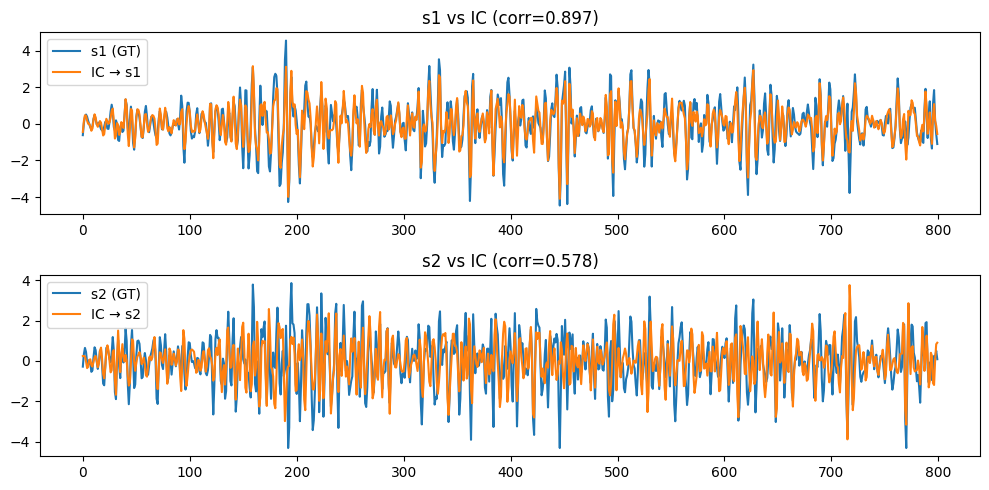

In [20]:
from scipy.optimize import linear_sum_assignment

# -----------------------------
# 1) Fuentes reales (ground truth)
# -----------------------------
emg = find_movement_rep(mat, "handOpen", rep=1)[0]
emg = eliminar_continua(emg)
emg = eliminar_outiliers(emg, k=8)
emg = escalar_canales(emg, metodo="rms")

s1 = emg[:, 25]
s2 = emg[:, 27]
S = np.vstack([s1, s2])

# limitar longitud para claridad
N = 800
S = S[:, :N]

#Matriz de mezcla
A = np.array([[0.2, 0.9],
              [0.5, 0.6]])

X = A @ S


ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2,   # pocas iteraciones
    tol=1e-12
)
S_hat = ica.fit_transform(X.T).T
S_aligned, C_final = match_and_fix(S, S_hat)

t = np.arange(N)

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(t, S[0], label="s1 (GT)")
plt.plot(t, S_aligned[0], label="IC → s1")
plt.title(f"s1 vs IC (corr={C_final[0,0]:.3f})")
plt.legend()

plt.subplot(2,1,2)
plt.plot(t, S[1], label="s2 (GT)")
plt.plot(t, S_aligned[1], label="IC → s2")
plt.title(f"s2 vs IC (corr={C_final[1,1]:.3f})")
plt.legend()

plt.tight_layout()
plt.show()


## Caso 3: Retardos temporales entre fuentes

$$
\begin{cases}
c_1(t) = s_1(t) + \beta\, s_2(t-\tau) \\
c_2(t) =  0.01* s_1(t-\tau) +s_2(t) 
\end{cases}
$$
Mezcla mas probable

In [21]:
import numpy as np
from sklearn.decomposition import FastICA


def _shift_with_zeros(x, tau):
    """
    Devuelve x(t - tau) usando padding con ceros.
    tau>0 => retraso (desplaza a la derecha): y[t] = x[t-tau]
    """
    x = np.asarray(x)
    N = x.shape[0]
    if tau == 0:
        return x.copy()
    if tau > 0:
        y = np.zeros_like(x)
        y[tau:] = x[:-tau]
        return y
    # tau < 0 => adelanto
    tau = -tau
    y = np.zeros_like(x)
    y[:-tau] = x[tau:]
    return y

def test_fastica_tau(s1, s2, tau, crop_mode="valid"):
    """
    Mezcla con retardo tau (en muestras) y aplica FastICA.
    crop_mode:
      - "valid": recorta a la zona donde ambos retardos están definidos (evita ceros)
      - "same": mantiene longitud N usando ceros (más realista, pero mete bordes)
    """
    s1 = np.asarray(s1).ravel()
    s2 = np.asarray(s2).ravel()
    N = len(s1)
    tau = int(tau)

    s1_tau = _shift_with_zeros(s1, tau)  # s1(t-tau)
    s2_tau = _shift_with_zeros(s2, tau)  # s2(t-tau)

    # Mezcla según tu ecuación
    c1 = s1 + s2_tau
    c2 = s2 + s1_tau

    X = np.c_[c1, c2]

    if crop_mode == "valid" and tau != 0:
        # Recortamos para quitar la zona contaminada por padding
        if tau > 0:
            sl = slice(tau, N)         # quitamos primeros tau
        else:
            sl = slice(0, N + tau)     # tau negativo => quitamos últimos |tau|
        X_use = X[sl, :]
        S_use = np.c_[s1, s2][sl, :]
    else:
        X_use = X
        S_use = np.c_[s1, s2]

    ica = FastICA(n_components=2, random_state=42, whiten='unit-variance')
    S_derived = ica.fit_transform(X_use)   # (Ns,2)
    W = ica.components_                    # (2,2)

    return X_use, S_use, S_derived, W



C:\Users\34648\AppData\Roaming\Python\Python311\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


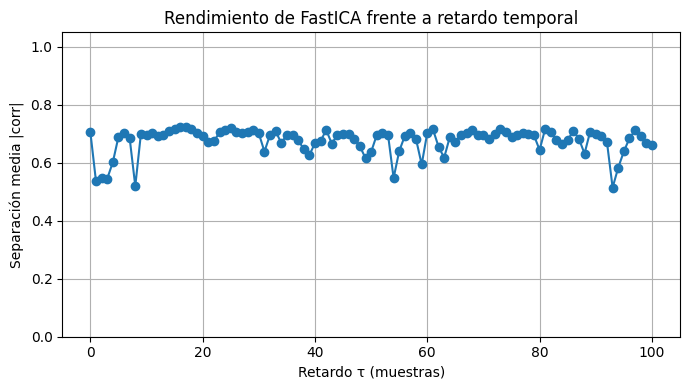

In [22]:

s1 = emg[:, 6]
s2 = emg[:, 27]

taus = np.arange(0, 101, 1)  # 0..50 muestras
scores_ica = []

for tau in taus:
    X, S_ref, S_derived, W = test_fastica_tau(
        s1, s2, tau, crop_mode="valid"
    )

    S_aligned, C_final = match_and_fix(S_ref.T, S_derived.T)

    score = np.mean(np.abs(np.diag(C_final)))
    scores_ica.append(score)

scores = np.array(scores_ica)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(taus, scores, marker="o")
plt.ylim(0, 1.05)
plt.grid(True)

plt.xlabel("Retardo τ (muestras)")
plt.ylabel("Separación media |corr|")
plt.title("Rendimiento de FastICA frente a retardo temporal")

plt.tight_layout()
plt.show()




C:\Users\34648\AppData\Roaming\Python\Python311\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


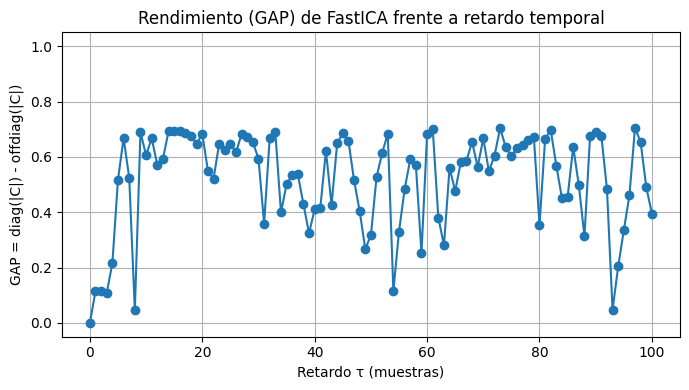

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Señales base
# -----------------------------
s1 = emg[:, 6]
s2 = emg[:, 27]

# -----------------------------
# Métrica GAP (2x2)
# -----------------------------
def gap_score(C_final):
    Cabs = np.abs(C_final)
    diag_mean = 0.5 * (Cabs[0, 0] + Cabs[1, 1])
    off_mean  = 0.5 * (Cabs[0, 1] + Cabs[1, 0])
    return diag_mean - off_mean

# -----------------------------
# ICA vs tau usando tu test_fastica_tau
# -----------------------------
taus = np.arange(0, 101, 1)
scores_gap_ica = []

for tau in taus:
    X, S_ref, S_derived, W = test_fastica_tau(
        s1, s2, tau, crop_mode="valid"
    )

    # match_and_fix trabaja con (n_sources, n_samples)
    S_aligned, C_final = match_and_fix(S_ref.T, S_derived.T)

    scores_gap_ica.append(gap_score(C_final))

scores_gap_ica = np.array(scores_gap_ica)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(taus, scores_gap_ica, marker="o")
plt.ylim(-0.05, 1.05)
plt.grid(True)

plt.xlabel("Retardo τ (muestras)")
plt.ylabel("GAP = diag(|C|) - offdiag(|C|)")
plt.title("Rendimiento (GAP) de FastICA frente a retardo temporal")

plt.tight_layout()
plt.show()


# CONCLUSIONES ICA

| Pros de ICA | Contras de ICA |
|------------|----------------|
| Permite separar fuentes **<span style="color:red">ESTADISTICAMENTE INDEPENDIENTES</span>** sin conocer la mezcla | Requiere que las fuentes sean **no gaussianas** (excepto una) |
| No necesita información previa detallada del sistema (modelo ciego) |  Sensible al **ruido** y a mezclas mal condicionadas |
| Puede recuperar señales ocultas en mezclas complejas | Supone **independencia estadística** |
| No requiere sincronización temporal entre fuentes | Resultados pueden variar según inicialización |

Para el caso de la separacion de señales musculares en un EMG, el mayor problema es que los músculos adyacentes presentan **correlacion y coactivación**, dificultando la implementación directa de ICA. 

No obstante existen otros algoritmos y estrategias para enfrentarse a mezclas donde las fuentes son estadísticamente dependientes.

IDEA PARA EVITAR DEPENDENCIA ESTADÍSTICA: Aplicar ICA en **<span style="color:red">frecuencia</span>**

# 1.2 ICA en frecuencia
### (AKA ICA convolutiva)

1.2.1 FFT + ICA
La idea es aplicar la trasnformada rapidad de fourier para realizar separación en el espectro  


   beta  tau          perm  corr_mean_abs_diag  sdr_db_mean  sdr_db_s1  \
0   0.0    0  (0, 1, 3, 2)            0.450755     2.827093   5.643889   
1   0.0    5  (2, 3, 1, 0)            0.468487     1.080881   1.202501   
2   0.0   10  (2, 3, 1, 0)            0.583786     1.893365   2.505158   
3   0.0   15  (2, 3, 1, 0)            0.659000     2.491937   2.799694   
4   0.0   20  (2, 3, 1, 0)            0.664619     2.554178   2.902564   

   sdr_db_s2 assignment                                 matched_corr  
0   0.010297     [0, 1]   [0.8528455356426433, -0.04866401894300623]  
1   0.959260     [0, 1]  [-0.49179595375620533, -0.4451771623893839]  
2   1.281573     [0, 1]   [-0.6620653130502104, -0.5055058333940227]  
3   2.184180     [0, 1]     [0.6893192477634603, 0.6286803616377408]  
4   2.205791     [0, 1]     [0.6981739127239197, 0.6310633923079202]  


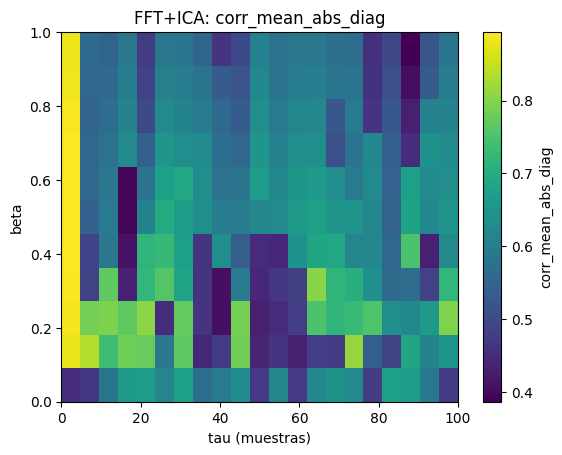

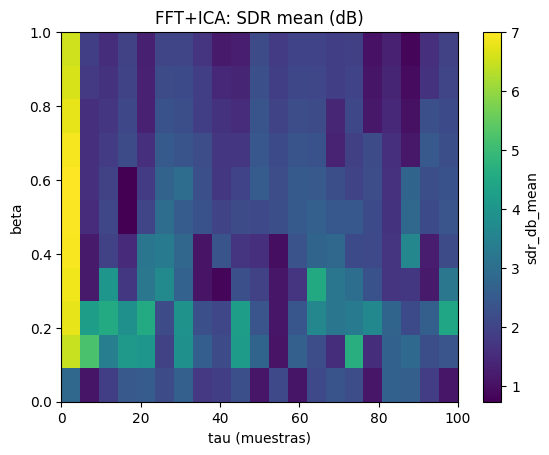

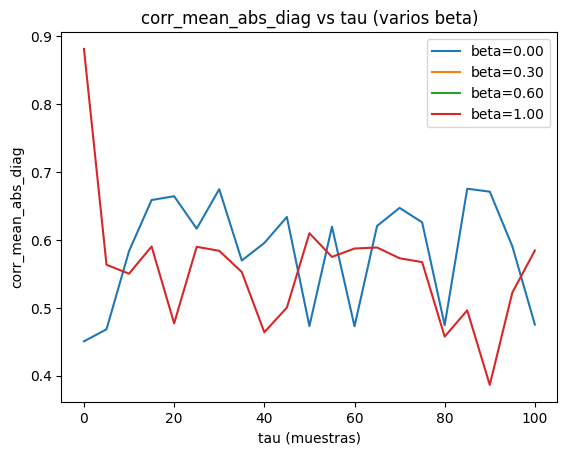

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import FastICA
from scipy.optimize import linear_sum_assignment
from itertools import permutations

# -----------------------------
# Mezcla con retardo
# -----------------------------
def delay_signal(x, tau):
    if tau <= 0:
        return x.copy()
    return np.concatenate([np.zeros(tau, dtype=float), x[:-tau]])

def make_mixture(s1, s2, beta=0.5, tau=10, alpha=0.01):
    s1 = np.asarray(s1, float)
    s2 = np.asarray(s2, float)
    assert s1.shape == s2.shape
    s1d = delay_signal(s1, tau)
    s2d = delay_signal(s2, tau)
    c1 = s1 + beta * s2d
    c2 = alpha * s1d + s2
    return c1, c2

# -----------------------------
# Métricas + matching
# -----------------------------
def corr_matrix(S_true, S_est):
    n = S_true.shape[0]
    C = np.zeros((n, n), float)
    for i in range(n):
        for j in range(n):
            a = S_true[i]
            b = S_est[j]
            if np.std(a) < 1e-12 or np.std(b) < 1e-12:
                C[i, j] = 0.0
            else:
                C[i, j] = np.corrcoef(a, b)[0, 1]
    return C

def match_hungarian(C):
    Cabs = np.abs(C)
    cost = 1.0 - Cabs
    rows, cols = linear_sum_assignment(cost)
    matched = C[rows, cols]
    return cols, matched

def scale_to_reference(s_ref, s_hat):
    denom = np.dot(s_hat, s_hat) + 1e-12
    a = np.dot(s_ref, s_hat) / denom
    return a * s_hat

def sdr_db(s_ref, s_hat):
    s_hat_s = scale_to_reference(s_ref, s_hat)
    num = np.sum(s_ref**2) + 1e-12
    den = np.sum((s_ref - s_hat_s)**2) + 1e-12
    return 10.0 * np.log10(num / den)

def eval_metrics(s1, s2, y1, y2):
    S_true = np.vstack([s1, s2])
    S_est  = np.vstack([y1, y2])

    C = corr_matrix(S_true, S_est)
    cols, matched = match_hungarian(C)

    S_est_m = S_est[cols, :]

    C2 = corr_matrix(S_true, S_est_m)
    corr_mean_abs_diag = float(np.mean(np.abs(np.diag(C2))))
    sdrs = [sdr_db(S_true[i], S_est_m[i]) for i in range(2)]

    return {
        "corr_mean_abs_diag": corr_mean_abs_diag,
        "sdr_db_mean": float(np.mean(sdrs)),
        "sdr_db_s1": float(sdrs[0]),
        "sdr_db_s2": float(sdrs[1]),
        "assignment": cols.tolist(),
        "matched_corr": matched.tolist(),
        "C_raw": C,
        "C_matched": C2,
    }

# -----------------------------
# FFT + ICA + IFFT (baseline)
# -----------------------------
def fft_ica_baseline(c1, c2, random_state=0, max_iter=5000, tol=1e-4):
    c1 = np.asarray(c1, float)
    c2 = np.asarray(c2, float)
    N = len(c1)
    assert len(c2) == N

    # rFFT (bins positivos)
    X1 = np.fft.rfft(c1)
    X2 = np.fft.rfft(c2)
    Xf = np.stack([X1, X2], axis=1)  # (n_bins, 2) complejo

    # Expandir a real: (n_bins, 4) = [Re ch1, Re ch2, Im ch1, Im ch2]
    Xr = np.concatenate([Xf.real, Xf.imag], axis=1)
    Xr = Xr - Xr.mean(axis=0, keepdims=True)

    # ICA con 4 componentes (full)
    ica = FastICA(
        n_components=4,
        whiten="unit-variance",
        random_state=random_state,
        max_iter=max_iter,
        tol=tol
    )
    Sr = ica.fit_transform(Xr)  # (n_bins, 4)
    return Sr, N

def best_complex_pairing_from_Sr(Sr, N, s1_true, s2_true):
    """
    Construye 2 espectros complejos a partir de 4 ICs reales probando permutaciones:
    Yf = Sr[:, p0:p2] + j*Sr[:, p2:p4]
    y = irfft(Yf)
    Elige la permutación con mejor corr_mean_abs_diag (como aquí conoces s1,s2).
    """
    def build_from_perm(p):
        Yf = Sr[:, p[0:2]] + 1j * Sr[:, p[2:4]]
        y1 = np.fft.irfft(Yf[:, 0], n=N)
        y2 = np.fft.irfft(Yf[:, 1], n=N)
        return y1, y2

    best_score = -np.inf
    best_perm = None
    best_y = None
    best_m = None

    for p in permutations(range(4), 4):
        y1, y2 = build_from_perm(p)
        m = eval_metrics(s1_true, s2_true, y1, y2)
        score = m["corr_mean_abs_diag"]
        if score > best_score:
            best_score = score
            best_perm = p
            best_y = (y1, y2)
            best_m = m

    return best_y, best_perm, best_m

def run_one(s1, s2, beta, tau, alpha=0.01, random_state=0):
    c1, c2 = make_mixture(s1, s2, beta=beta, tau=tau, alpha=alpha)
    Sr, N = fft_ica_baseline(c1, c2, random_state=random_state)
    (y1, y2), perm, metrics = best_complex_pairing_from_Sr(Sr, N, s1, s2)
    out = {
        "beta": float(beta),
        "tau": int(tau),
        "perm": perm,
        **{k: v for k, v in metrics.items() if not k.startswith("C_")}  # sin matrices
    }
    return out

# -----------------------------
# Barridos beta / tau
# -----------------------------
def sweep_beta_tau(
    s1, s2,
    betas=np.linspace(0, 1, 11),
    taus=np.arange(0, 101, 5),
    alpha=0.01,
    random_state=0
):
    rows = []
    for beta in betas:
        for tau in taus:
            try:
                r = run_one(s1, s2, beta=beta, tau=tau, alpha=alpha, random_state=random_state)
            except Exception as e:
                # Si algo falla, lo anotamos y seguimos
                r = {
                    "beta": float(beta),
                    "tau": int(tau),
                    "error": repr(e)
                }
            rows.append(r)
    df = pd.DataFrame(rows)
    return df

# -----------------------------
# Visualización rápida
# -----------------------------
def plot_heatmap(df, value_col, betas=None, taus=None, title=None):
    # Pivot a tabla beta x tau
    piv = df.pivot_table(index="beta", columns="tau", values=value_col, aggfunc="mean")
    plt.figure()
    plt.imshow(piv.values, aspect="auto", origin="lower",
               extent=[piv.columns.min(), piv.columns.max(), piv.index.min(), piv.index.max()])
    plt.colorbar(label=value_col)
    plt.xlabel("tau (muestras)")
    plt.ylabel("beta")
    plt.title(title or f"Heatmap: {value_col}")
    plt.show()

def plot_curves_vs_tau(df, beta_values, value_col="corr_mean_abs_diag"):
    plt.figure()
    for b in beta_values:
        sub = df[df["beta"] == b].sort_values("tau")
        plt.plot(sub["tau"].values, sub[value_col].values, label=f"beta={b:.2f}")
    plt.xlabel("tau (muestras)")
    plt.ylabel(value_col)
    plt.title(f"{value_col} vs tau (varios beta)")
    plt.legend()
    plt.show()

# -----------------------------
# USO
# -----------------------------
s1 = emg[:, 6]
s2 = emg[:, 27]
df = sweep_beta_tau(s1, s2,
                     betas=np.linspace(0,1,11),
                     taus=np.arange(0,101,5),
                     alpha=0.01,
                     random_state=0)
print(df.head())
#
# # Heatmaps
plot_heatmap(df, "corr_mean_abs_diag", title="FFT+ICA: corr_mean_abs_diag")
plot_heatmap(df, "sdr_db_mean", title="FFT+ICA: SDR mean (dB)")
#
# # Curvas para beta concretos
plot_curves_vs_tau(df, beta_values=[0.0, 0.3, 0.6, 1.0], value_col="corr_mean_abs_diag")



In [25]:
s1 = emg[:, 6]
s2 = emg[:, 27]

def stft_ica_freq(X, fs=1000, nperseg=512, noverlap=384, n_sources=2, random_state=0):
    """
    X: (n_samples, n_channels) real
    Devuelve S_hat: (n_samples, n_sources) real (aprox), y STFT separada Y (f, t, n_sources) compleja.
    """
    X = np.asarray(X, float)
    X = X - X.mean(axis=0, keepdims=True)
    X = escalar_canales(X, metodo="zscore")

    n_samples, n_ch = X.shape

    # 1) STFT por canal
    Z_list = []
    for ch in range(n_ch):
        f, tt, Z = stft(X[:, ch], fs=fs, nperseg=nperseg, noverlap=noverlap, boundary=None)
        Z_list.append(Z)  # (n_freq, n_frames)
    Z = np.stack(Z_list, axis=2)  # (n_freq, n_frames, n_ch)

    n_freq, n_frames, _ = Z.shape

    # 2) ICA por bin de frecuencia
    Y = np.zeros((n_freq, n_frames, n_sources), dtype=np.complex128)

    ica = FastICA(n_components=n_sources, whiten="unit-variance", max_iter=2000, tol=1e-4,
                  random_state=random_state)

    for k in range(n_freq):
        Xfk = Z[k, :, :]  # (n_frames, n_ch) complejo

        # Construir real: (n_frames, 2*n_ch)
        X_real = np.concatenate([Xfk.real, Xfk.imag], axis=1)

        # ICA sobre frames (muestras) vs features (canales*2)
        S_real = ica.fit_transform(X_real)  # (n_frames, n_sources)

        # OJO: aquí perdemos fase explícita; alternativa mejor: reconstruir compleja usando mixing,
        # pero para un baseline funciona usar la fuente "real" como magnitud/coef.
        # Para mantener un complejo "razonable", ponemos la salida en parte real (baseline).
        Y[k, :, :] = S_real + 0j

    # 3) (Opcional pero importante) Alineación por frecuencia (permuta/signo)
    # Implementación mínima: alinear por correlación de |Y| entre bins adyacentes
    for k in range(1, n_freq):
        prev = np.abs(Y[k-1, :, :])
        cur  = np.abs(Y[k, :, :])

        # matriz de similitud (n_sources x n_sources)
        C = np.corrcoef(prev.T, cur.T)[:n_sources, n_sources:]
        # asignación greedy simple (para n_sources=2 suele bastar)
        if n_sources == 2:
            if np.abs(C[0,0]) + np.abs(C[1,1]) < np.abs(C[0,1]) + np.abs(C[1,0]):
                Y[k, :, [0,1]] = Y[k, :, [1,0]]

    # 4) iSTFT por fuente
    S_hat = []
    for s in range(n_sources):
        _, x_rec = istft(Y[:, :, s], fs=fs, nperseg=nperseg, noverlap=noverlap, input_onesided=True, boundary=None)
        # recorta a longitud original
        x_rec = x_rec[:n_samples] if len(x_rec) >= n_samples else np.pad(x_rec, (0, n_samples-len(x_rec)))
        S_hat.append(x_rec)

    S_hat = np.stack(S_hat, axis=1)  # (n_samples, n_sources)
    return S_hat, (f, tt, Y)

# Ejemplo de uso:
# emg: (samples, channels). Para tu prueba toy de 2 canales: X = np.c_[c1, c2]
# S_hat, stft_pack = stft_ica_freq(X, fs=1000, nperseg=512, noverlap=384, n_sources=2)


## PCA para encontrar el número de fuentes óptimo



# Separación ciega según independencia temporal
## SOBI

### Caso 1: dos fuentes con atenuacion bidireccional $\beta$
Empezando con el caso más trivial, la primera prueba es probar a separar 2 señales de canales mas o menos independientes segun las siguientes combinaciones:
- $c_1=s_1 +\beta*s_2$
- $c_2=0.01*s_1 +s_2$

In [26]:


s1 = emg[:, 6]
s2 = emg[:, 27]
S_original = np.c_[s1, s2]  # (N,2)

lags, rxy = correlacion_cruzada(s1, s2, max_lag=200)

#Solo lags positivos
mask = lags > 0
lags_pos = lags[mask]
rxy_pos  = rxy[mask]

#Escoger los K mas importantes 
K = 100
K = min(K, len(lags_pos))
top = np.argsort(np.abs(rxy_pos))[-K:]
tau_corr = np.sort(lags_pos[top]).astype(int)

def test_SOBI_beta(s1, s2, beta, delays):
    c1 = s1 + beta * s2
    c2 = s2 + 0.01 * s1
    X = np.c_[c1, c2]  

    S_derived, W = sobi(X, delays=delays, n_sources=2)  

    return X, S_derived, W

for beta_test in [0.01, 0.5, 900]:
    X, S_derived, W = test_SOBI_beta(s1, s2, beta_test, tau_corr)

    # S_derived es (N,2) -> para match_and_fix quieres (2,N)
    S_aligned, C_final = match_and_fix(S_original.T, S_derived.T)

    print(f"SOBI finalizado para beta = {beta_test}")
    print("Matriz de correlación final C:\n", C_final)



SOBI finalizado para beta = 0.01
Matriz de correlación final C:
 [[ 0.94927146 -0.31445777]
 [ 0.31346212  0.94960071]]
SOBI finalizado para beta = 0.5
Matriz de correlación final C:
 [[ 0.94927146 -0.31445777]
 [ 0.31346212  0.94960071]]
SOBI finalizado para beta = 900
Matriz de correlación final C:
 [[ 0.94927146 -0.31445777]
 [ 0.31346212  0.94960071]]


Mientras que SOBI converga, ES INDEPENDIENTE DE BETA

## Caso 2: Retardos temporales entre fuentes

$$
\begin{cases}
c_1(t) = s_1(t) + \beta\, s_2(t-\tau) \\
c_2(t) =  \beta\, s_1(t-\tau) +s_2(t) 
\end{cases}
$$

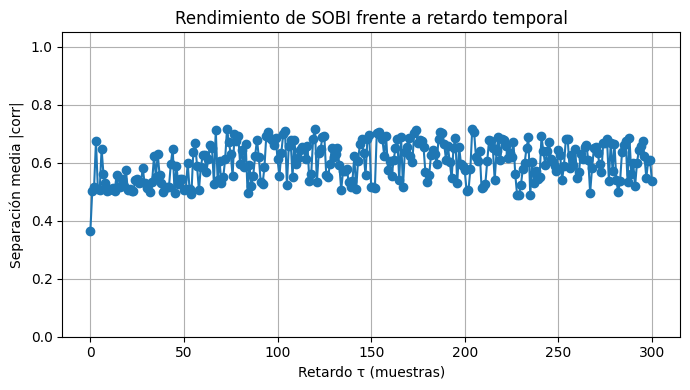

In [27]:

s1 = emg[:, 6]
s2 = emg[:, 27]

def shift_with_zeros(x, tau):
    x = np.asarray(x).ravel()
    N = len(x)
    tau = int(tau)

    if tau == 0:
        return x.copy()
    y = np.zeros_like(x)
    if tau > 0:
        y[tau:] = x[:-tau]
    else:
        tau = -tau
        y[:-tau] = x[tau:]
    return y


def test_sobi_tau(s1, s2, tau, delays=None, crop_mode="valid"):
    """
    Genera mezcla con retardo tau y separa con SOBI.

    Returns:
      X_use:   (Ns, 2)
      S_ref:   (Ns, 2) señales originales recortadas
      S_hat:   (Ns, 2) señales estimadas por SOBI
      W:       (2, 2) matriz separación
    """
    s1 = np.asarray(s1).ravel()
    s2 = np.asarray(s2).ravel()
    N = len(s1)
    tau = int(tau)

    s1_tau = shift_with_zeros(s1, tau)  # s1(t-tau)
    s2_tau = shift_with_zeros(s2, tau)  # s2(t-tau)

    #Mezcla
    c1 = s1 + s2_tau
    c2 = s2 + s1_tau
    X = np.c_[c1, c2]  

    #Recortar (revisar esto)
    if crop_mode == "valid" and tau != 0:
        if tau > 0:
            sl = slice(tau, N)
        else:
            sl = slice(0, N + tau)
        X_use = X[sl, :]
        S_ref = np.c_[s1, s2][sl, :]
    else:
        X_use = X
        S_ref = np.c_[s1, s2]

    # Delays para SOBI: solo positivos y distintos de 0
    # (si no pasas nada, uso una lista razonable)
    if delays is None:
        delays = np.array([1, 2, 3, 5, 7, 10, 15, 20, 30, 40, 50], dtype=int)
    else:
        delays = np.asarray(delays, dtype=int)
        delays = delays[delays > 0]


    S_hat, W = sobi(X_use, delays=delays, n_sources=2)

    return X_use, S_ref, S_hat, W

# -----------------------------
# Barrido de taus y métrica
# -----------------------------
taus = np.arange(0, 301, 1)   
scores_sobi = []

for tau in taus:
    X, S_ref, S_derived, W = test_sobi_tau(s1, s2, tau, crop_mode="valid")

    S_aligned, C_final = match_and_fix(S_ref.T, S_derived.T)

    score = np.mean(np.abs(np.diag(C_final)))
    scores_sobi.append(score)

scores_sobi = np.array(scores_sobi)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(taus, scores_sobi, marker="o")
plt.ylim(0, 1.05)
plt.grid(True)

plt.xlabel("Retardo τ (muestras)")
plt.ylabel("Separación media |corr|")
plt.title("Rendimiento de SOBI frente a retardo temporal")

plt.tight_layout()
plt.show()


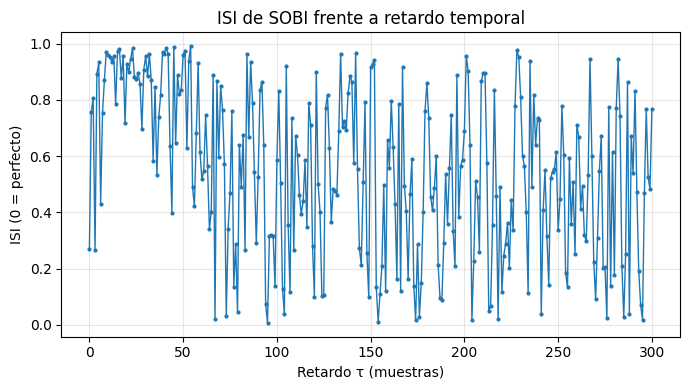

In [28]:
# -----------------------------
import numpy as np

def isi_from_gain(G, eps=1e-12):
    """
    ISI tipo Amari basado en matriz de ganancia G (n x n).
    0 = perfecto, mayor = peor. Nunca debe ser negativo.
    """
    G = np.asarray(G, float)
    A = np.abs(G) + eps
    n = A.shape[0]

    row_term = np.sum(A.sum(axis=1) / A.max(axis=1) - 1.0)
    col_term = np.sum(A.sum(axis=0) / A.max(axis=0) - 1.0)

    isi = (row_term + col_term) / (2.0 * n * (n - 1))

    # Por estabilidad numérica (debería ser innecesario, pero asegura no-negatividad)
    return float(max(0.0, isi))

taus = np.arange(0, 301, 1)
isi_sobi = []

for tau in taus:
    X, S_ref, S_derived, W = test_sobi_tau(s1, s2, tau, crop_mode="valid")

    # match_and_fix: devuelve S_aligned y una matriz de "ganancia" por correlación
    S_aligned, C_final = match_and_fix(S_ref.T, S_derived.T)

    # ISI sobre la matriz de ganancia (aquí C_final)
    isi_val = isi_from_gain(C_final)
    isi_sobi.append(isi_val)

isi_sobi = np.array(isi_sobi)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(taus, isi_sobi, marker="o", markersize=2, linewidth=1)
plt.grid(True, alpha=0.3)

plt.xlabel("Retardo τ (muestras)")
plt.ylabel("ISI (0 = perfecto)")
plt.title("ISI de SOBI frente a retardo temporal")

plt.tight_layout()
plt.show()

In [29]:
print(np.min(isi_sobi))


0.00676166582153398


In [30]:
import numpy as np

s1 = emg[:, 25]
s2 = emg[:, 27]

def best_abs_corr(a, b, max_lag=0):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    N = min(len(a), len(b))
    a = a[:N]; b = b[:N]

    def corr_at_lag(lag):
        if lag > 0:
            a2 = a[lag:]
            b2 = b[:-lag]
        elif lag < 0:
            lag = -lag
            a2 = a[:-lag]
            b2 = b[lag:]
        else:
            a2 = a; b2 = b
        if len(a2) < 10:
            return np.nan
        sa = np.std(a2); sb = np.std(b2)
        if sa == 0 or sb == 0:
            return np.nan
        return float(np.corrcoef(a2, b2)[0, 1])

    best = 0.0
    for lag in range(-max_lag, max_lag+1):
        c = corr_at_lag(lag)
        if np.isnan(c):
            continue
        best = max(best, abs(c))
    return best

def corr_gain_matrix(S_ref_2xN, S_hat_2xN, max_lag=0):
    S_ref = np.asarray(S_ref_2xN)
    S_hat = np.asarray(S_hat_2xN)
    n = S_ref.shape[0]
    C = np.zeros((n, n), float)
    for i in range(n):
        for j in range(n):
            C[i, j] = best_abs_corr(S_ref[i], S_hat[j], max_lag=max_lag)
    return C

def isi_from_gain(G_abs):
    """
    ISI tipo Amari/ISI sobre una matriz de ganancias |G|.
    Devuelve 0 si separación ideal.
    """
    G = np.asarray(G_abs, float)
    n = G.shape[0]
    eps = 1e-12

    row_terms = 0.0
    for i in range(n):
        m = np.max(G[i, :]) + eps
        row_terms += (np.sum(G[i, :]) / m) - 1.0

    col_terms = 0.0
    for j in range(n):
        m = np.max(G[:, j]) + eps
        col_terms += (np.sum(G[:, j]) / m) - 1.0

    return (row_terms + col_terms) / (2.0 * n * (n - 1))



In [31]:
taus = np.arange(0, 100)
isi_sobi = []
isi_ica  = []

for tau in taus:
    X, S_ref, S_hat_sobi, W = test_sobi_tau(s1, s2, tau, crop_mode="valid")
    C = corr_gain_matrix(S_ref.T, S_hat_sobi.T, max_lag=int(tau)+5)  # lag-aware
    isi_sobi.append(isi_from_gain(C))

    X, S_ref, S_hat_ica, W = test_fastica_tau(s1, s2, tau, crop_mode="valid")
    C = corr_gain_matrix(S_ref.T, S_hat_ica.T, max_lag=int(tau)+5)
    isi_ica.append(isi_from_gain(C))


C:\Users\34648\AppData\Roaming\Python\Python311\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


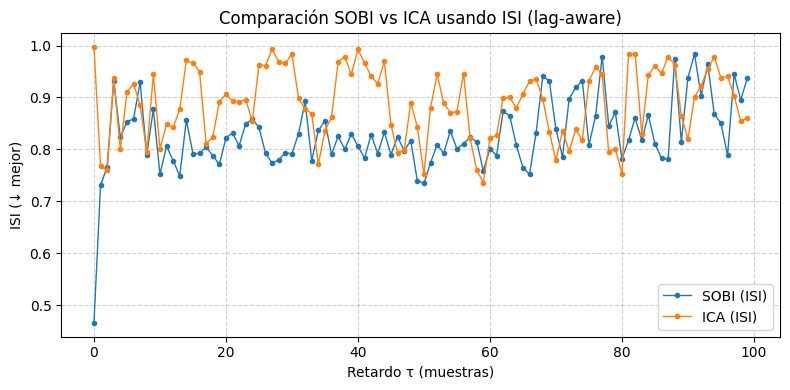

In [32]:
plt.figure(figsize=(8,4))
plt.plot(taus, isi_sobi, label="SOBI (ISI)", marker="o", markersize=3, linewidth=1)
plt.plot(taus, isi_ica,  label="ICA (ISI)",  marker="o", markersize=3, linewidth=1)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlabel("Retardo τ (muestras)")
plt.ylabel("ISI (↓ mejor)")
plt.title("Comparación SOBI vs ICA usando ISI (lag-aware)")
plt.legend()
plt.tight_layout()
plt.show()


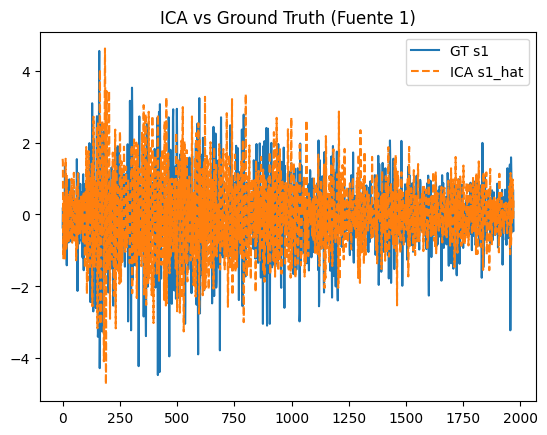

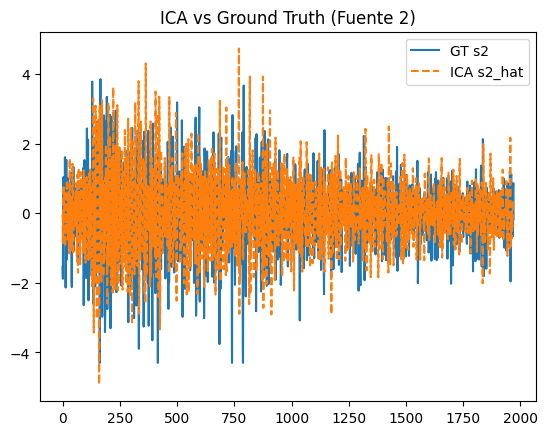

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
tau=30
# Ejecutar ICA
X, S_ref, S_hat_ica, W = test_fastica_tau(s1, s2, tau, crop_mode="valid")

# Matriz de correlación lag-aware
C = corr_gain_matrix(S_ref.T, S_hat_ica.T, max_lag=int(tau)+5)

# Matching óptimo
cost = 1 - np.abs(C)
rows, cols = linear_sum_assignment(cost)

S_hat_matched = S_hat_ica[:, cols]

# ---- GRÁFICA ICA ----
plt.figure()
plt.plot(S_ref[:,0], label="GT s1")
plt.plot(S_hat_matched[:,0], linestyle="--", label="ICA s1_hat")
plt.title("ICA vs Ground Truth (Fuente 1)")
plt.legend()
plt.show()

plt.figure()
plt.plot(S_ref[:,1], label="GT s2")
plt.plot(S_hat_matched[:,1], linestyle="--", label="ICA s2_hat")
plt.title("ICA vs Ground Truth (Fuente 2)")
plt.legend()
plt.show()


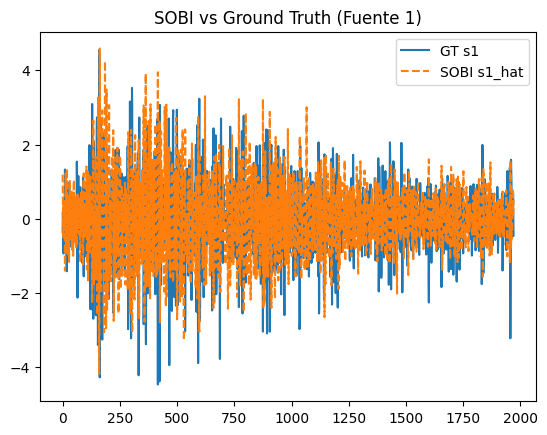

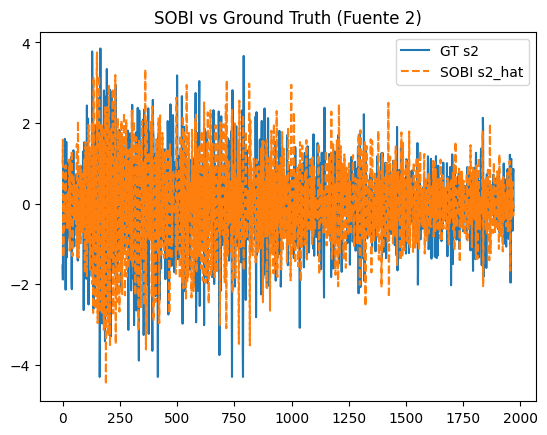

In [34]:
# Ejecutar SOBI
X, S_ref, S_hat_sobi, W = test_sobi_tau(s1, s2, tau, crop_mode="valid")

# Matriz de correlación lag-aware
C = corr_gain_matrix(S_ref.T, S_hat_sobi.T, max_lag=int(tau)+5)

# Matching óptimo
cost = 1 - np.abs(C)
rows, cols = linear_sum_assignment(cost)

S_hat_matched = S_hat_sobi[:, cols]

# ---- GRÁFICA SOBI ----
plt.figure()
plt.plot(S_ref[:,0], label="GT s1")
plt.plot(S_hat_matched[:,0], linestyle="--", label="SOBI s1_hat")
plt.title("SOBI vs Ground Truth (Fuente 1)")
plt.legend()
plt.show()

plt.figure()
plt.plot(S_ref[:,1], label="GT s2")
plt.plot(S_hat_matched[:,1], linestyle="--", label="SOBI s2_hat")
plt.title("SOBI vs Ground Truth (Fuente 2)")
plt.legend()
plt.show()


# SOBI: Separación de fuentes con retardos

## Modelo de mezcla con retardo

$$
\begin{cases}
c_1(t) = s_1(t) + \beta\, s_2(t-\tau) \\
c_2(t) = s_2(t) + \beta\, s_1(t-\tau)
\end{cases}
$$


### 1. Centrado

$$
\tilde{\mathbf{X}} = \mathbf{X} - \mathbb{E}[\mathbf{X}]
$$



### 2. Covarianza (retardo cero)

$$
\mathbf{R}_x(0) = \mathbb{E}\left[\tilde{\mathbf{X}}(t) \tilde{\mathbf{X}}^T(t)\right]
$$



### 3️. Blanqueo (Whitening)

$$
\mathbf{R}_x(0) = \mathbf{E} \mathbf{D} \mathbf{E}^T
$$

$$
\mathbf{V} = \mathbf{E} \mathbf{D}^{-1/2}, \quad
\mathbf{Z}(t) = \mathbf{V}^T \tilde{\mathbf{X}}(t)
$$



### 4️. Autocorrelación con retardos

Para cada retardo $\tau_k$:

$$
\mathbf{R}_z(\tau_k) = \mathbb{E}\left[\mathbf{Z}(t) \mathbf{Z}^T(t-\tau_k)\right]
$$



## 5️. Diagonalización conjunta (SOBI)

$$
\mathbf{U}^T \mathbf{R}_z(\tau_k) \mathbf{U} \approx \text{diagonal}, \quad \forall \tau_k
$$



## 6️. Estimación de fuentes

$$
\mathbf{W} = \mathbf{V} \mathbf{U}, \quad
\mathbf{S}(t) = \mathbf{X} \mathbf{W}
$$

**Notas:**
- $\mathbf{S}$: fuentes estimadas (cada columna = fuente)  
- $\mathbf{W}$: matriz de separación  
- Ambigüedad: escala, signo y orden de las fuentes


# 3. Separación Semi-Ciega
Para poder realizar este tipo de separación, se debe tener una información a priori del sistema o de alguna de las señales esperadas. 

En función del criterio de información que usemos existen diferentes tipos:

- Regresion
- Correlation Constrained
- Kernel Constrained
- 2CFactICA (los dos)

In [ ]:
import numpy as np

def corr(a, b, eps=1e-12):
    a = a - np.mean(a)
    b = b - np.mean(b)
    return float(np.dot(a, b) / (np.sqrt(np.dot(a, a) * np.dot(b, b)) + eps))

def cancel_s2_from_c1(c1, r, ridge_alpha=0.0, eps=1e-12):
    """
    c1 = s1 + beta*s2
    r  ≈ s2 (referencia ruidosa)
    Estima beta_hat por OLS (o Ridge si ridge_alpha>0) y devuelve s1_hat.
    """
    c1c = c1 - np.mean(c1)
    rc  = r  - np.mean(r)

    denom = np.dot(rc, rc) + ridge_alpha + eps
    beta_hat = np.dot(c1c, rc) / denom
    s1_hat = c1c - beta_hat * rc
    return s1_hat, beta_hat


N = 2


# "Fuentes" de ejemplo (cámbialo por tus EMG reales)
s1 = emg[:, 26]
s2 = emg[:, 27]

beta = 0.7
c1 = s1 + beta * s2

# referencia imperfecta de s2
sigma_r = 0.01   # sube esto para empeorar la referencia
r = s2 + sigma_r * s1

# aplica cancelación
s1_hat, beta_hat = cancel_s2_from_c1(c1, r, ridge_alpha=0.0)

# -------------------------
# MÉTRICAS contra GT
# -------------------------
rho_s1 = corr(s1_hat, s1)          # recuperación de s1
leak   = corr(s1_hat, s2)          # fuga de s2 dentro de s1_hat
rho_r  = corr(s1_hat, r)           # (opcional) correlación residual con referencia

print("beta real:   ", beta)
print("beta_hat:   ", beta_hat)
print("corr(s1_hat, s1) =", rho_s1)
print("corr(s1_hat, s2) =", leak)
print("corr(s1_hat, r)  =", rho_r)


beta real:    0.7
beta_hat:    1.1615423096922703
corr(s1_hat, s1) = 0.8842852403510124
corr(s1_hat, s2) = -0.008842870248694994
corr(s1_hat, r)  = 7.667459172788973e-16


: 